# 16 — Proposal figure preview: two-panel WCS overlay

**Purpose:** Preliminary version of the two-panel proposal figure showing both the real
and simulated images, plate-solved with WCS coordinate overlays, catalog-matched star
annotations, and a north-angle compass fiducial.

This is the figure *skeleton*. Spectra-angle extraction is not yet implemented.
Once `wcs_geometry.py` is complete, the grating-angle arrow will replace the GT
placeholder drawn here for the sim panel.

**Run from the `Python (spectrangle WSL)` kernel.**  
Local `solve-field` is required; remote astrometry.net is NOT used.

| Panel | File | Scale | Solver index |
|:------|:-----|:------|:-------------|
| Real  | `fuji6_asi178_100_15s.fit`  | ~80 arcsec/px | index-4117 |
| Sim   | `100lmm50mm_sim.fits`       | ~10 arcsec/px | index-4108 |


In [1]:
import sys, shutil, warnings, time, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales

_pkg_root = str(Path('..').resolve())
if _pkg_root not in sys.path:
    sys.path.insert(0, _pkg_root)

from extractor import extract_stars
from extractor.platesolve import solve_plate, LocalSolveFieldError, _col_array
from extractor.wcsangle import center_wcs_angle_metrics, angle_diff_deg

BACKEND_CFG = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
INDEX_DIR   = Path('/mnt/c/Users/bassd/astrometry-data/4100/')

def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)

import extractor
print(f'extractor   : {extractor.__version__}  ({extractor.__file__})')
print(f'Python      : {sys.version.split()[0]}')
print(f'Platform    : {platform.system()} {platform.release()}')
if platform.system() == 'Windows':
    print('\n*** WARNING: Windows kernel — local solve-field will fail.')
    print('    Switch to the Python (spectrangle WSL) kernel.')
sf = shutil.which('solve-field')
print(f'solve-field : {sf or "NOT FOUND"}')
print(f'backend cfg : {BACKEND_CFG}  exists={Path(BACKEND_CFG).exists()}')


extractor   : 0.2.0  (/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/extractor/__init__.py)
Python      : 3.11.0rc1
Platform    : Linux 5.15.167.4-microsoft-standard-WSL2
solve-field : /usr/bin/solve-field
backend cfg : /mnt/c/Users/bassd/.astrometry/backend.cfg  exists=True


## Parameters — all tunable values in one place

Adjust the stretch parameters here to control how each panel looks in the figure.


In [9]:
# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR  = Path('..') / 'data' / 'fig'
OUT_DIR   = Path('..') / 'out' / 'proposal_fig'
OUT_DIR.mkdir(parents=True, exist_ok=True)

REAL_FILE = DATA_DIR / 'fuji6_asi178_100_15s.fit'
SIM_FILE  = DATA_DIR / '100lmm50mm_sim.fits'

# ── Real image: solve parameters ───────────────────────────────────────────────
REAL_SCALE_LOW    = 70.0        # arcsec/px lower bound
REAL_SCALE_HIGH   = 95.0        # arcsec/px upper bound
REAL_TWEAK_ORDER  = 5
REAL_TIMEOUT      = 120         # seconds
REAL_INDEX_FILE   = str(INDEX_DIR / 'index-4117.fits')

# ── Sim image: solve parameters ────────────────────────────────────────────────
SIM_SCALE_LOW     = 8.0
SIM_SCALE_HIGH    = 12.0
SIM_TWEAK_ORDER   = 4
SIM_TIMEOUT       = 180
SIM_INDEX_FILE    = str(INDEX_DIR / 'index-4108.fits')

# ── Brightness stretch ─────────────────────────────────────────────────────────
# Background subtraction Gaussian sigma (px).
BG_SIGMA_REAL     = 50.0
BG_SIGMA_SIM      = 50.0

# Percentile clip applied before arcsinh. Raise VHI to show fainter features;
# lower it to prevent the brightest stars from dominating.
VLO_PCT_REAL      = 0.3
VHI_PCT_REAL      = 99.
VLO_PCT_SIM       = 0.3
VHI_PCT_SIM       = 99.

# ── Figure aesthetics ──────────────────────────────────────────────────────────
FIG_W             = 16.0        # figure width  (inches)
FIG_H             = 6.5         # figure height (inches)
FIG_DPI           = 150
FIG_OUT_PATH      = OUT_DIR / 'proposal_figure_preview.png'

DARK_BG           = True        # True = dark background; False = light (for print)

DET_MARKER_SIZE   = 14          # detected-source marker area (pt²)
MATCH_MARKER_SIZE = 70          # catalog-matched marker area (pt²)
MATCH_LW          = 1.3         # matched-source circle line width (pt)

# North/East compass fiducial
ARROW_LENGTH_FRAC = 0.07        # arrow length as fraction of min(nx, ny)
ARROW_POS_X       = 0.10        # arrow base x as fraction of image width
ARROW_POS_Y       = 0.12        # arrow base y as fraction of image height
COMPASS_COLOR     = '#ffe066'   # bright yellow
COMPASS_FONTSIZE  = 13

# For the sim panel: also draw the GT grating angle as a dashed line to preview
# what the spectra-angle arrow will look like once extraction is implemented.
# Set False to omit the GT placeholder.
SHOW_GT_ANGLE_SIM = True
GT_COLOR          = '#ff6b6b'   # red dashed (placeholder, not yet measured)

TITLE_FS          = 11
LABEL_FS          = 10
ANN_FS            = 8.5
LEGEND_FS         = 8
SUPTITLE_FS       = 12

# ── Cached solve paths (reuse earlier notebooks where possible) ────────────────
NB10_FID = Path('..') / 'out' / 'local_bootstrap_10' / 'fiducial_result.pkl'
NB10_SRC = Path('..') / 'out' / 'local_bootstrap_10' / 'sources.pkl'

REAL_SOLVE_CACHE = OUT_DIR / 'real_fiducial.pkl'
REAL_SRC_CACHE   = OUT_DIR / 'real_sources.pkl'
SIM_SOLVE_CACHE  = OUT_DIR / 'sim_fiducial.pkl'
SIM_SRC_CACHE    = OUT_DIR / 'sim_sources.pkl'

print('File check:')
for p, label in [(REAL_FILE,'real'), (SIM_FILE,'sim')]:
    print(f'  {label:6s} : {p}  exists={p.exists()}')
print(f'Output dir  : {OUT_DIR.resolve()}')
print(f'nb10 cache  : fid={NB10_FID.exists()}  src={NB10_SRC.exists()}')


File check:
  real   : ../data/fig/fuji6_asi178_100_15s.fit  exists=True
  sim    : ../data/fig/100lmm50mm_sim.fits  exists=True
Output dir  : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig
nb10 cache  : fid=True  src=True


## Load images and compute display stretch


Image summary:
  Real: 3096×2080 px
  Sim: 3096×2080 px  MASKANG=337.00  RA0DEG=40.00  DEC0DEG=65.00  PSARC=9.90  ROTDEG=0.00


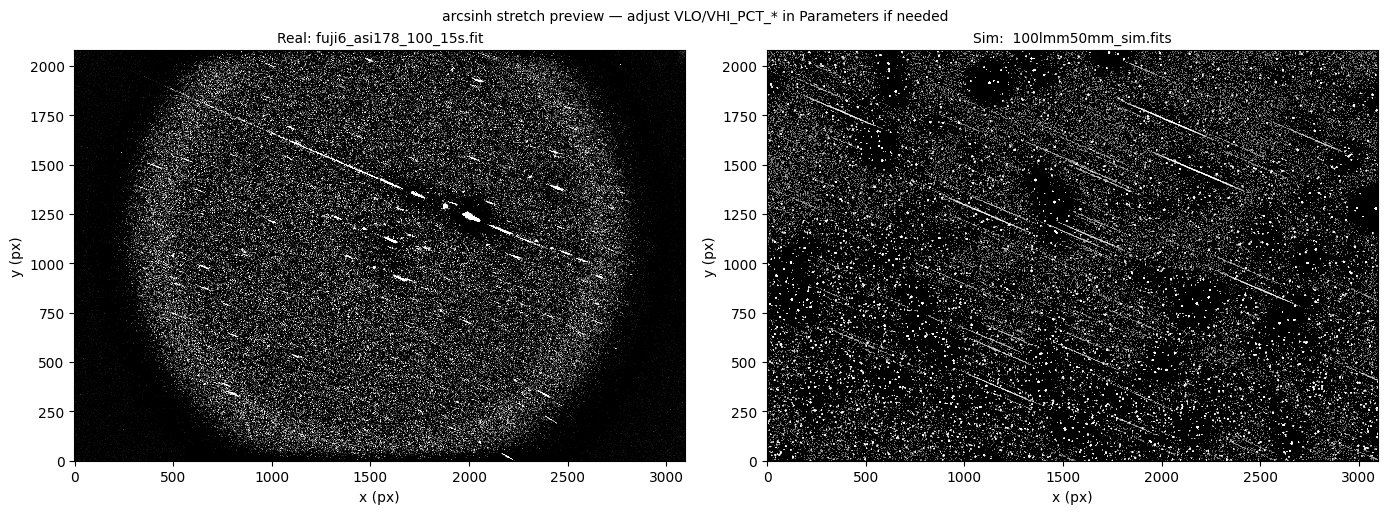

In [10]:
def load_and_stretch(fits_path, bg_sigma, vlo_pct, vhi_pct):
    """Load FITS, compute background-subtracted arcsinh display array."""
    with fits.open(fits_path) as hdul:
        image  = hdul[0].data.astype(np.float32)
        header = hdul[0].header.copy()
    ny, nx = image.shape
    bg   = gaussian_filter(image, sigma=bg_sigma)
    proc = np.clip(image - bg, 0, None)
    lo, hi = np.percentile(proc[np.isfinite(proc)], [vlo_pct, vhi_pct])
    disp = np.arcsinh(np.clip(proc, lo, hi))
    return image, header, disp, float(np.arcsinh(lo)), float(np.arcsinh(hi)), nx, ny

(image_real, hdr_real, disp_real, dlo_real, dhi_real, nx_real, ny_real) = \
    load_and_stretch(REAL_FILE, BG_SIGMA_REAL, VLO_PCT_REAL, VHI_PCT_REAL)
(image_sim, hdr_sim, disp_sim, dlo_sim, dhi_sim, nx_sim, ny_sim) = \
    load_and_stretch(SIM_FILE, BG_SIGMA_SIM, VLO_PCT_SIM, VHI_PCT_SIM)

print('Image summary:')
for name, nx, ny, hdr in [('Real', nx_real, ny_real, hdr_real),
                           ('Sim',  nx_sim,  ny_sim,  hdr_sim)]:
    print(f'  {name}: {nx}×{ny} px', end='')
    for k in ['MASKANG', 'RA0DEG', 'DEC0DEG', 'PSARC', 'ROTDEG']:
        v = hdr.get(k)
        if v is not None:
            print(f'  {k}={float(v):.2f}', end='')
    print()

# Quick look — raw display to verify stretch before committing to solve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, disp, dlo, dhi, title in [
    (axes[0], disp_real, dlo_real, dhi_real, f'Real: {REAL_FILE.name}'),
    (axes[1], disp_sim,  dlo_sim,  dhi_sim,  f'Sim:  {SIM_FILE.name}'),
]:
    ax.imshow(disp, origin='lower', cmap='gray', vmin=dlo, vmax=dhi,
              aspect='equal', interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
fig.suptitle('arcsinh stretch preview — adjust VLO/VHI_PCT_* in Parameters if needed',
             fontsize=10)
fig.tight_layout()
plt.show()


## Source detection (cached)


In [11]:
def get_sources(image, fits_path, cache_path, alt_cache=None):
    """Detect stars or load from cache.  alt_cache is tried first."""
    for p, label in [(alt_cache, 'alt'), (cache_path, 'local')]:
        if p is not None and Path(p).exists():
            with open(p, 'rb') as f:
                xs, ys, fl = pickle.load(f)
            print(f'  {fits_path.name}: {len(xs)} sources  (from {label} cache)')
            return xs, ys, fl
    print(f'  {fits_path.name}: detecting sources...')
    xs, ys, fl = extract_stars(image, max_sources=300, mask_spectra=True)
    with open(cache_path, 'wb') as f:
        pickle.dump((xs, ys, fl), f)
    print(f'  {fits_path.name}: {len(xs)} sources detected and cached.')
    return xs, ys, fl

xs_real, ys_real, fl_real = get_sources(
    image_real, REAL_FILE, REAL_SRC_CACHE, alt_cache=NB10_SRC)
xs_sim, ys_sim, fl_sim = get_sources(
    image_sim, SIM_FILE, SIM_SRC_CACHE)

print(f'\nSource counts:  real={len(xs_real)}   sim={len(xs_sim)}')


  fuji6_asi178_100_15s.fit: 255 sources  (from alt cache)
  100lmm50mm_sim.fits: detecting sources...
  100lmm50mm_sim.fits: 287 sources detected and cached.

Source counts:  real=255   sim=287


## Plate-solve: real image

Tries nb10 fiducial cache first (same image, same solver parameters),
falls back to running a fresh local solve.


In [12]:
def _load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def _save_pkl(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

# Try nb10 cache (same real image, already solved to order-5 SIP)
if NB10_FID.exists():
    print(f'Loading real-image solve from nb10 cache: {NB10_FID}')
    result_real = _load_pkl(NB10_FID)
elif REAL_SOLVE_CACHE.exists():
    print(f'Loading real-image solve from local cache: {REAL_SOLVE_CACHE}')
    result_real = _load_pkl(REAL_SOLVE_CACHE)
else:
    print(f'Running real-image solve ({len(xs_real)} sources, order {REAL_TWEAK_ORDER})...')
    _extra = ['--index', REAL_INDEX_FILE] if Path(REAL_INDEX_FILE).exists() else None
    _t0 = time.time()
    try:
        result_real = solve_plate(
            xs=xs_real, ys=ys_real,
            image_width=nx_real, image_height=ny_real,
            original_header=hdr_real,
            backend='local', backend_config=BACKEND_CFG,
            scale_units='arcsecperpix',
            scale_low=REAL_SCALE_LOW, scale_high=REAL_SCALE_HIGH,
            tweak_order=REAL_TWEAK_ORDER,
            output_dir=OUT_DIR / 'real_solve',
            timeout=REAL_TIMEOUT, verbose=True,
            extra_args=_extra,
        )
    except LocalSolveFieldError as e:
        print(f'Solve failed: {e}')
        result_real = None
    print(f'Finished in {time.time()-_t0:.1f}s')
    if result_real is not None:
        _save_pkl(result_real, REAL_SOLVE_CACHE)

if result_real is None:
    print('WARNING: real image solve failed — WCS panel will be unavailable.')
    wcs_real, metrics_real = None, None
else:
    wcs_real     = _make_wcs(result_real.header)
    metrics_real = center_wcs_angle_metrics(wcs_real, image_real.shape, compute_east=True)
    _ps = float(np.mean(np.abs(proj_plane_pixel_scales(wcs_real))) * 3600)
    print(f'Real solve OK:')
    print(f'  matched       : {len(result_real.matched_x)}')
    print(f'  plate scale   : {_ps:.2f} arcsec/px')
    print(f'  θ_north       : {metrics_real.north_angle_deg:.4f}° (CCW from +x)')
    print(f'  θ_east        : {metrics_real.east_angle_deg:.4f}°')
    print(f'  center RA/Dec : {metrics_real.ra_deg:.4f}° / {metrics_real.dec_deg:.4f}°')


Loading real-image solve from nb10 cache: ../out/local_bootstrap_10/fiducial_result.pkl
Real solve OK:
  matched       : 86
  plate scale   : 80.39 arcsec/px
  θ_north       : -107.0058° (CCW from +x)
  θ_east        : 163.0386°
  center RA/Dec : 113.4236° / 30.4264°


## Plate-solve: simulated image

`100lmm50mm_sim.fits` has not been solved before (nb15 used `110lmm50mm.fits`).
We pass the RA/Dec hint from the FITS header to speed up the solve.


In [13]:
if SIM_SOLVE_CACHE.exists():
    print(f'Loading sim-image solve from cache: {SIM_SOLVE_CACHE}')
    result_sim = _load_pkl(SIM_SOLVE_CACHE)
else:
    _ra_hint  = float(hdr_sim.get('RA0DEG',  0))
    _dec_hint = float(hdr_sim.get('DEC0DEG', 0))
    print(f'Running sim-image solve ({len(xs_sim)} sources, order {SIM_TWEAK_ORDER})...')
    print(f'  RA/Dec hint from header: ({_ra_hint:.3f}°, {_dec_hint:.3f}°)')

    _extra_sim = [
        '--index', SIM_INDEX_FILE,
        '--ra',    str(_ra_hint),
        '--dec',   str(_dec_hint),
        '--radius','10',
    ] if Path(SIM_INDEX_FILE).exists() else None

    _t0 = time.time()
    try:
        result_sim = solve_plate(
            xs=xs_sim, ys=ys_sim,
            image_width=nx_sim, image_height=ny_sim,
            original_header=hdr_sim,
            backend='local', backend_config=BACKEND_CFG,
            scale_units='arcsecperpix',
            scale_low=SIM_SCALE_LOW, scale_high=SIM_SCALE_HIGH,
            tweak_order=SIM_TWEAK_ORDER,
            output_dir=OUT_DIR / 'sim_solve',
            timeout=SIM_TIMEOUT, verbose=True,
            extra_args=_extra_sim,
        )
    except LocalSolveFieldError as e:
        print(f'Solve failed: {e}')
        result_sim = None
    print(f'Finished in {time.time()-_t0:.1f}s')
    if result_sim is not None:
        _save_pkl(result_sim, SIM_SOLVE_CACHE)

if result_sim is None:
    print('WARNING: sim image solve failed — WCS panel will be unavailable.')
    wcs_sim, metrics_sim = None, None
else:
    wcs_sim     = _make_wcs(result_sim.header)
    metrics_sim = center_wcs_angle_metrics(wcs_sim, image_sim.shape, compute_east=True)
    _ps = float(np.mean(np.abs(proj_plane_pixel_scales(wcs_sim))) * 3600)
    gt_mask = float(hdr_sim.get('MASKANG', float('nan')))
    print(f'Sim solve OK:')
    print(f'  matched       : {len(result_sim.matched_x)}')
    print(f'  plate scale   : {_ps:.2f} arcsec/px  (GT: {float(hdr_sim.get("PSARC",0)):.2f})')
    print(f'  θ_north       : {metrics_sim.north_angle_deg:.4f}° (CCW from +x)')
    print(f'  θ_east        : {metrics_sim.east_angle_deg:.4f}°')
    print(f'  center RA/Dec : {metrics_sim.ra_deg:.4f}° / {metrics_sim.dec_deg:.4f}°')
    print(f'  GT MASKANG    : {gt_mask:.1f}°  (ground-truth grating angle; not yet extracted)')


Running sim-image solve (287 sources, order 4)...
  RA/Dec hint from header: (40.000°, 65.000°)
Wrote 287 sources → ../out/proposal_fig/sim_solve/xylist.fits
Running: /usr/bin/solve-field ../out/proposal_fig/sim_solve/xylist.fits --width 3096 --height 2080 --scale-units arcsecperpix --scale-low 8.0 --scale-high 12.0 --tweak-order 4 --dir ../out/proposal_fig/sim_solve --backend-config /mnt/c/Users/bassd/.astrometry/backend.cfg --overwrite --no-plots --index /mnt/c/Users/bassd/astrometry-data/4100/index-4108.fits --ra 40.0 --dec 65.0 --radius 10
  Field 1 did not solve (index index-4112.fits, field objects 171-180).
  Field 1 did not solve (index index-4111.fits, field objects 171-180).
  Field 1 did not solve (index index-4110.fits, field objects 171-180).
  Field 1 did not solve (index index-4109.fits, field objects 171-180).
  Field 1 did not solve (index index-4107.fits, field objects 171-180).
  Field 1 did not solve (index index-4116.fits, field objects 181-190).
  Field 1 did not 

## Proposal figure

Two-panel figure with WCS coordinate grids, catalog-matched star circles,
and a north+east compass fiducial.  For the simulation panel, the GT
grating angle (`MASKANG`) is also drawn as a dashed placeholder to preview
the final figure layout.

Tune all visual parameters in the **Parameters** cell above.


/tmp/ipykernel_3297/2451222933.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=LEGEND_FS, loc='upper right',
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarn

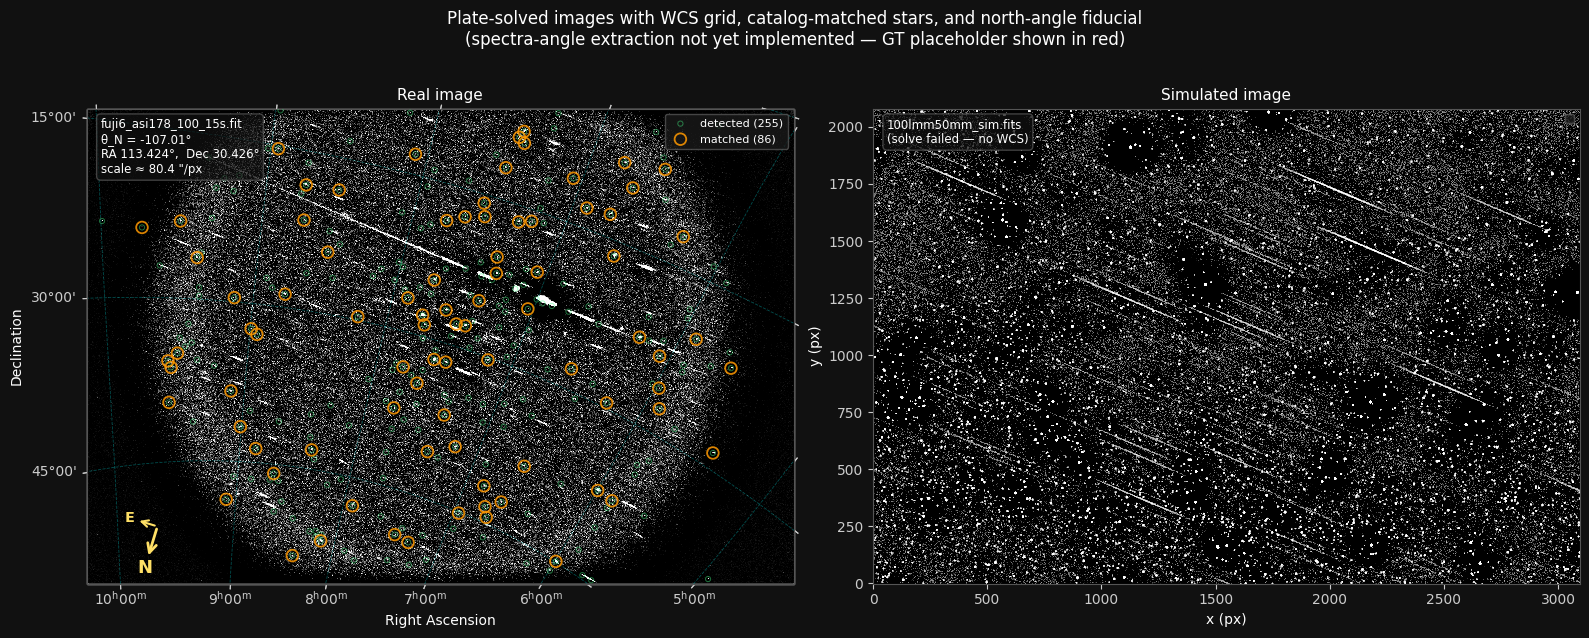


Figure saved to: /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/out/proposal_fig/proposal_figure_preview.png


In [15]:
def draw_compass(ax, x_px, y_px, length_px, north_angle_deg,
                 east_angle_deg=None, color='yellow', fontsize=12):
    """Draw N (and optionally E) compass arrows at pixel position (x_px, y_px)."""
    pix = ax.get_transform('pixel')
    th_n = np.radians(north_angle_deg)
    dx_n = length_px * np.cos(th_n)
    dy_n = length_px * np.sin(th_n)

    ax.annotate('',
        xy=(x_px + dx_n, y_px + dy_n), xytext=(x_px, y_px),
        xycoords=pix, textcoords=pix,
        arrowprops=dict(arrowstyle='->', color=color, lw=2.0,
                        mutation_scale=16))
    ax.text(x_px + 1.30*dx_n, y_px + 1.30*dy_n, 'N',
            transform=pix, color=color, fontsize=fontsize,
            fontweight='bold', ha='center', va='center')

    if east_angle_deg is not None:
        th_e = np.radians(east_angle_deg)
        L_e  = length_px * 0.65           # east arrow shorter than north
        dx_e = L_e * np.cos(th_e)
        dy_e = L_e * np.sin(th_e)
        ax.annotate('',
            xy=(x_px + dx_e, y_px + dy_e), xytext=(x_px, y_px),
            xycoords=pix, textcoords=pix,
            arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                            mutation_scale=12))
        ax.text(x_px + 1.35*dx_e, y_px + 1.35*dy_e, 'E',
                transform=pix, color=color, fontsize=fontsize*0.80,
                fontweight='bold', ha='center', va='center')


def draw_angle_line(ax, x_px, y_px, length_px, angle_deg,
                    color='red', linestyle='--', lw=2.0, label=None):
    """Draw a double-headed line at angle_deg (CCW from +x) through (x_px, y_px)."""
    pix = ax.get_transform('pixel')
    th = np.radians(angle_deg)
    half = length_px / 2.0
    x0, y0 = x_px - half*np.cos(th), y_px - half*np.sin(th)
    x1, y1 = x_px + half*np.cos(th), y_px + half*np.sin(th)
    ax.plot([x0, x1], [y0, y1], color=color, linestyle=linestyle,
            linewidth=lw, transform=pix, solid_capstyle='round')
    if label is not None:
        ax.text(x1 + 0.05*half, y1 + 0.05*half, label,
                transform=pix, color=color, fontsize=10,
                fontstyle='italic', ha='left', va='bottom')


# ── Apply style ───────────────────────────────────────────────────────────────
_bg_col   = '#111111' if DARK_BG else 'white'
_fg_col   = 'white'   if DARK_BG else 'black'
_grid_col = 'cyan'    if DARK_BG else '#2266cc'
_leg_fc   = '#1a1a1a' if DARK_BG else 'white'
_leg_ec   = '#555555' if DARK_BG else '#aaaaaa'
_ann_fc   = '#111111' if DARK_BG else 'white'

plt.rcParams.update({
    'figure.facecolor': _bg_col,
    'text.color': _fg_col,
    'axes.labelcolor': _fg_col,
    'xtick.color': '#cccccc' if DARK_BG else '#333333',
    'ytick.color': '#cccccc' if DARK_BG else '#333333',
    'axes.edgecolor': '#555555' if DARK_BG else '#999999',
    'legend.facecolor': _leg_fc,
    'legend.edgecolor': _leg_ec,
})

# ── Build figure ──────────────────────────────────────────────────────────────
panels = [
    dict(image=disp_real, vlo=dlo_real, vhi=dhi_real,
         wcs=wcs_real, result=result_real, metrics=metrics_real,
         nx=nx_real, ny=ny_real, hdr=hdr_real,
         name='Real image', file=REAL_FILE.name,
         gt_angle=None),                          # no GT for real image
    dict(image=disp_sim,  vlo=dlo_sim,  vhi=dhi_sim,
         wcs=wcs_sim,  result=result_sim,  metrics=metrics_sim,
         nx=nx_sim,  ny=ny_sim, hdr=hdr_sim,
         name='Simulated image', file=SIM_FILE.name,
         gt_angle=float(hdr_sim.get('MASKANG', np.nan))),
]

fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor=_bg_col)

for col, p in enumerate(panels):
    # Use WCSAxes projection if a valid WCS solution exists, else plain axes
    if p['wcs'] is not None:
        ax = fig.add_subplot(1, 2, col + 1, projection=p['wcs'])
    else:
        ax = fig.add_subplot(1, 2, col + 1)
    ax.set_facecolor(_bg_col)

    # ── Image ─────────────────────────────────────────────────────────────────
    ax.imshow(p['image'], origin='lower', cmap='gray',
              vmin=p['vlo'], vmax=p['vhi'],
              aspect='equal', interpolation='nearest')

    # ── WCS coordinate grid ───────────────────────────────────────────────────
    if p['wcs'] is not None:
        ax.coords.grid(True, color=_grid_col, alpha=0.30,
                       linestyle='--', linewidth=0.6)
        ax.coords['ra'].set_major_formatter('hh:mm')
        ax.coords['dec'].set_major_formatter('dd:mm')
        ax.coords['ra'].set_axislabel('Right Ascension', fontsize=LABEL_FS,
                                       color=_fg_col)
        ax.coords['dec'].set_axislabel('Declination', fontsize=LABEL_FS,
                                        color=_fg_col)
    else:
        ax.set_xlabel('x (px)', fontsize=LABEL_FS)
        ax.set_ylabel('y (px)', fontsize=LABEL_FS)

    # ── Source overlays ───────────────────────────────────────────────────────
    if p['result'] is not None:
        pix = ax.get_transform('pixel') if p['wcs'] is not None else ax.transData

        # Detected sources (all submitted to solver)
        ax.scatter(p['result'].detected_x, p['result'].detected_y,
                   transform=pix,
                   s=DET_MARKER_SIZE, facecolors='none',
                   edgecolors='#44ff88', linewidths=0.7, alpha=0.45,
                   label=f'detected ({len(p["result"].detected_x)})',
                   zorder=3)

        # Catalog-matched sources
        if p['result'].corr_table is not None:
            mx = np.asarray(p['result'].corr_table['field_x'], dtype=float)
            my = np.asarray(p['result'].corr_table['field_y'], dtype=float)
            ax.scatter(mx, my, transform=pix,
                       s=MATCH_MARKER_SIZE, facecolors='none',
                       edgecolors='#ff9900', linewidths=MATCH_LW, alpha=0.85,
                       label=f'matched ({len(mx)})',
                       zorder=4)

    # ── North/East compass fiducial ───────────────────────────────────────────
    if p['metrics'] is not None:
        arrow_len = min(p['nx'], p['ny']) * ARROW_LENGTH_FRAC
        ax_px     = p['nx'] * ARROW_POS_X
        ay_px     = p['ny'] * ARROW_POS_Y
        draw_compass(ax, ax_px, ay_px, arrow_len,
                     p['metrics'].north_angle_deg,
                     p['metrics'].east_angle_deg,
                     color=COMPASS_COLOR, fontsize=COMPASS_FONTSIZE)

    # ── GT grating angle (sim only, MASKANG placeholder) ──────────────────────
    if (SHOW_GT_ANGLE_SIM
            and p['gt_angle'] is not None
            and not np.isnan(p['gt_angle'])
            and p['metrics'] is not None):
        # MASKANG is in pixel-space degrees (CCW from +x) per the tele-img-sim
        # convention.  Draw it through the image center as a preview of what
        # the extracted spectra-angle arrow will look like.
        gt_line_len = min(p['nx'], p['ny']) * 0.30
        draw_angle_line(ax,
                        p['nx'] / 2.0, p['ny'] / 2.0,
                        gt_line_len, p['gt_angle'],
                        color=GT_COLOR, linestyle='--', lw=1.8,
                        label='GT grating angle')

    # ── Legend ────────────────────────────────────────────────────────────────
    ax.legend(fontsize=LEGEND_FS, loc='upper right',
              facecolor=_leg_fc, edgecolor=_leg_ec)

    # ── Annotation box ────────────────────────────────────────────────────────
    if p['metrics'] is not None:
        _ps = float(np.mean(np.abs(proj_plane_pixel_scales(p['wcs']))) * 3600)
        ann_lines = [
            p['file'],
            f'θ_N = {p["metrics"].north_angle_deg:.2f}°',
            f'RA {p["metrics"].ra_deg:.3f}°,  Dec {p["metrics"].dec_deg:.3f}°',
            f'scale ≈ {_ps:.1f} "/px',
        ]
        if p['gt_angle'] is not None and not np.isnan(p['gt_angle']):
            ann_lines.append(f'GT MASKANG = {p["gt_angle"]:.1f}° (placeholder)')
        ann = '\n'.join(ann_lines)
    else:
        ann = f'{p["file"]}\n(solve failed — no WCS)'

    ax.text(0.02, 0.98, ann,
            transform=ax.transAxes,
            fontsize=ANN_FS, color=_fg_col,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor=_ann_fc, alpha=0.75, edgecolor=_leg_ec,
                      boxstyle='round,pad=0.35'))

    ax.set_title(p['name'], fontsize=TITLE_FS, color=_fg_col, pad=6)

fig.suptitle(
    'Plate-solved images with WCS grid, catalog-matched stars, '
    'and north-angle fiducial\n'
    '(spectra-angle extraction not yet implemented — GT placeholder shown in red)',
    fontsize=SUPTITLE_FS, color=_fg_col, y=1.01)
fig.tight_layout()
fig.savefig(FIG_OUT_PATH, dpi=FIG_DPI, bbox_inches='tight',
            facecolor=_bg_col)
plt.show()
print(f'\nFigure saved to: {FIG_OUT_PATH.resolve()}')


# Customisation notes

| What to change | Parameter(s) |
|:---|:---|
| Brighter/dimmer image | `VLO_PCT_*`, `VHI_PCT_*` |
| Background suppression | `BG_SIGMA_*` |
| Arrow size / position | `ARROW_LENGTH_FRAC`, `ARROW_POS_X/Y` |
| Light background (for print) | `DARK_BG = False` |
| Hide GT grating placeholder | `SHOW_GT_ANGLE_SIM = False` |
| Figure resolution | `FIG_DPI` |

**To add the real extracted spectra angle** (future work): after `wcs_geometry.py` 
is implemented, call `pixel_angle_to_sky_angle()` per trace, combine the results, 
and replace the `MASKANG` GT placeholder with `draw_angle_line(ax, ..., measured_pix_angle)` 
for both panels.
